<a href="https://colab.research.google.com/github/njones61/xslope/blob/main/docs/seepage/xslope_seep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XSLOPE - Seepage Analysis

This notebook illustrates how to use xslope to solve a seepage problem using a 2D finite element solution.

## Install xslope and import functions

In [1]:
# Install the xslope package
# - Basic install (limit equilibrium only): pip install xslope
# - Full install (with FEM features): pip install xslope[fem]

%%capture
!apt-get update && apt-get install -y libgl1-mesa-glx libglu1-mesa # required by gmsh
!pip install xslope[fem]==0.1.9
!pip install gmsh

In [2]:
# Import functions

import xslope as xslope

from xslope.fileio import load_slope_data, print_dictionary
from xslope.mesh import build_polygons, build_mesh_from_polygons, export_mesh_to_json, import_mesh_from_json
from xslope.plot import plot_inputs, plot_mesh, plot_polygons, plot_polygons_separately
from xslope.plot_seep import plot_seep_data, plot_seep_solution
from xslope.seep import build_seep_data, run_seepage_analysis, save_seep_data_to_json, export_seep_solution

## Upload Excel template

In [3]:
# Upload excel input template for selected problem

from google.colab import files
upload = files.upload()
file_name = list(upload.keys())[0]

Saving xslope_earth_dam2.xlsx to xslope_earth_dam2.xlsx


## Load slope data

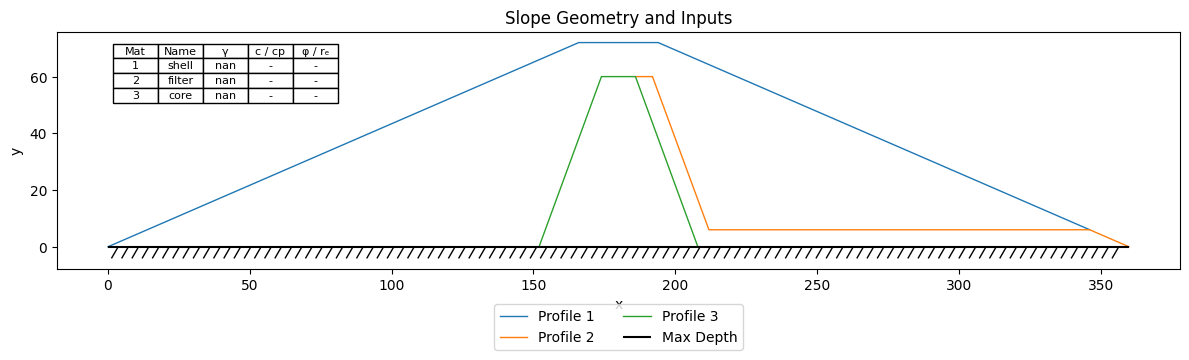

In [4]:
slope_data = load_slope_data(file_name)

plot_inputs(slope_data)


In [5]:
# @title Select element type {"run":"auto"}
elem_type = "tri3" # @param ["tri3","tri6","quad4","quad8","quad9"]
elem_size = 4 # @param {"type":"number"}
auto_size = True # @param {"type":"boolean"}
# @markdown **Note:** If autosize is selected, elem_size will be ignored

if auto_size:
  x_range = [min(x for x, _ in slope_data['ground_surface'].coords), max(x for x, _ in slope_data['ground_surface'].coords)]
  elem_size = (x_range[1] - x_range[0]) / 100
  print(f"Element size: {elem_size}")

Element size: 3.6


## Build mesh

Mesh tolerance for boundary conditions: 0.202998


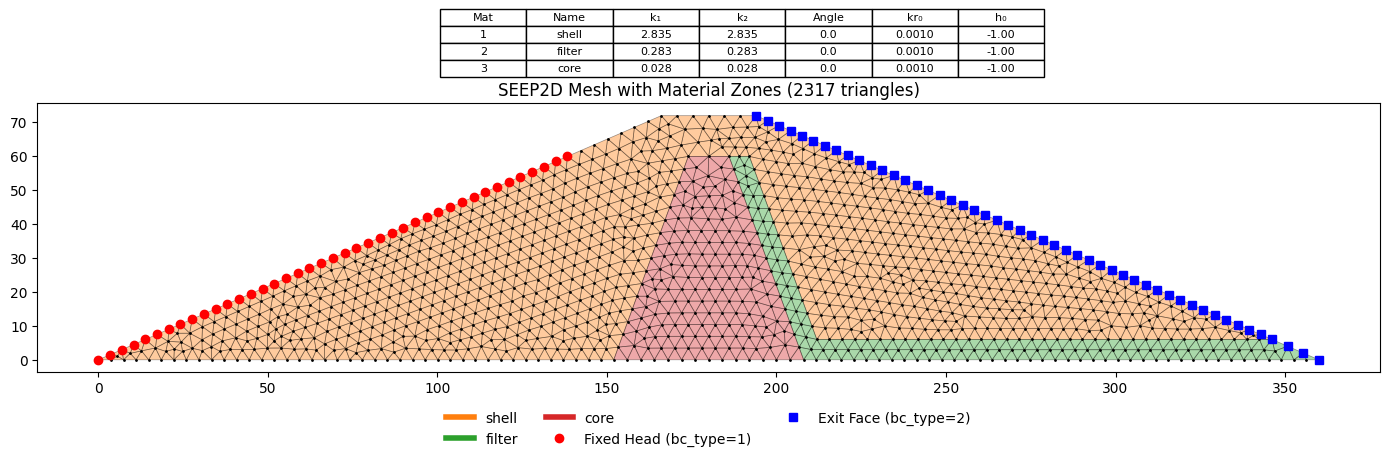

In [6]:
polygons = build_polygons(slope_data)

mesh = build_mesh_from_polygons(polygons, elem_size, elem_type)

seep_data = build_seep_data(mesh, slope_data)

plot_seep_data(seep_data, show_nodes=True, show_bc=True, material_table=True, label_elements=False, label_nodes=False)

## Run seepage analysis

In [7]:
solution = run_seepage_analysis(seep_data)

Solving UNCONFINED seepage problem...
Number of fixed-head nodes: 41
Number of exit face nodes: 49
Starting unsaturated flow iteration...
Convergence tolerance: 7.200000e-03
Iteration 1: residual = 8.110001e-01, relax = 1.000, 30/49 exit face active
Iteration 2: residual = 4.479937e-01, relax = 1.000, 22/49 exit face active
Iteration 3: residual = 2.456678e-01, relax = 1.000, 16/49 exit face active
Iteration 4: residual = 1.760813e-01, relax = 1.000, 12/49 exit face active
Iteration 5: residual = 2.887552e-01, relax = 1.000, 9/49 exit face active
Iteration 6: residual = 2.402160e-01, relax = 1.000, 7/49 exit face active
Iteration 7: residual = 1.740277e-01, relax = 1.000, 6/49 exit face active
Iteration 8: residual = 2.161581e-01, relax = 1.000, 5/49 exit face active
Iteration 9: residual = 3.116117e-01, relax = 1.000, 4/49 exit face active
Iteration 10: residual = 3.133131e-01, relax = 1.000, 4/49 exit face active
Iteration 15: residual = 1.749823e-01, relax = 1.000, 4/49 exit face ac

## Plot Results

In [43]:
# @title Select plotting options {"run":"auto"}
variable = "head" # @param ["head","u","v_mag","i_mag"]
flowlines = True # @param {"type":"boolean"}
levels = 20 # @param {"type":"integer"}

base_mat = 3 # @param {"type":"integer"}
fill_contours = False # @param {"type":"boolean"}
alpha = 0.4 # @param {"type":"number"}
phreatic = True # @param {"type":"boolean"}

vectors = False # @param {"type":"boolean"}
vector_scale = 0.1 # @param {"type":"number"}

mesh = False # @param {"type":"boolean"}

Plotting 2317 linear triangles, 0 quadratic triangles, 0 linear quads, 0 8-node quads, 0 9-node quads


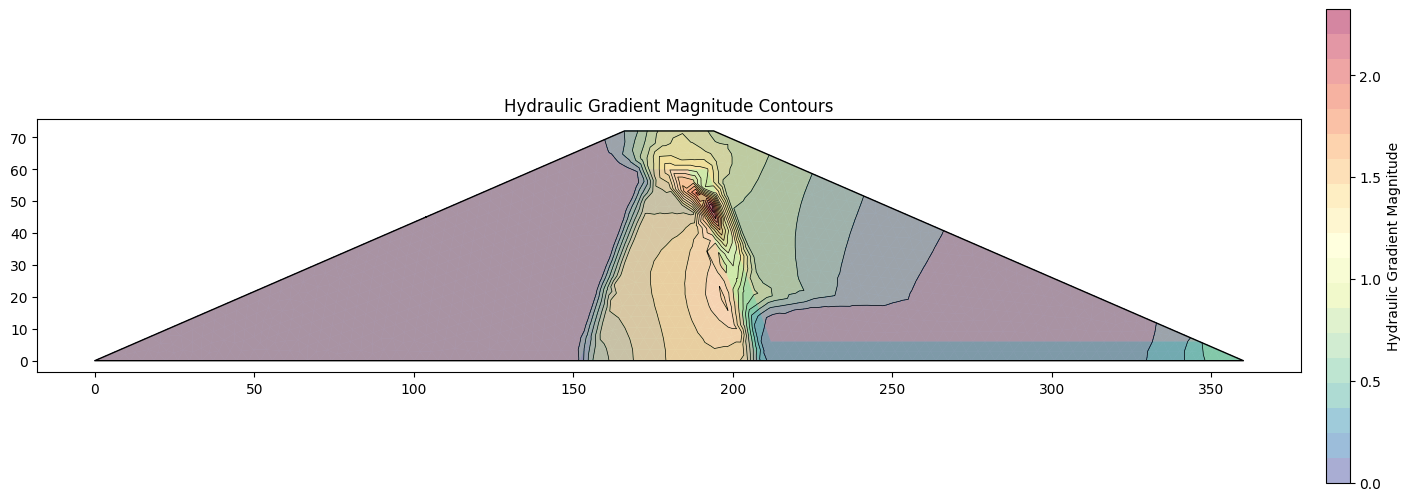

In [40]:
plot_seep_solution(seep_data,
                   solution,
                   variable=variable,
                   flowlines=flowlines,
                   levels=levels,
                   base_mat=base_mat,
                   fill_contours=fill_contours,
                   alpha=alpha,
                   phreatic=phreatic,
                   vectors=vectors,
                   vector_scale=vector_scale,
                   mesh=mesh)